#  Self-Pruning Neural Network (CIFAR-10)

This project implements a neural network that learns to **prune its own weights during training** using a gating mechanism.

Instead of removing weights after training, the model dynamically identifies and suppresses less important connections, resulting in a **sparse and efficient architecture**.

In [12]:
# Core PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Dataset & utilities
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Visualization
import matplotlib.pyplot as plt
import numpy as np

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


Using device: cuda


## Model Architecture

We implement a custom `PrunableLinear` layer where each weight is associated with a learnable **gate parameter**.

- Gate values are obtained using a sigmoid function
- Each weight is multiplied by its corresponding gate
- If a gate approaches 0 → the weight is effectively pruned

This allows the network to learn which connections are important during training.

In [13]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        # Standard weights and bias
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))


        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        # Converting the scores to gates between 0 and 1 using sigmoid activation function
        gates = torch.sigmoid(self.gate_scores)

        # Applying pruning (element-wise multiplication)
        pruned_weights = self.weight * gates

        # Performing linear operation
        return F.linear(x, pruned_weights, self.bias)

layer = PrunableLinear(5, 3)

x = torch.randn(2, 5)   # batch size = 2, input features = 5
output = layer(x)

print("Output shape:", output.shape)

Output shape: torch.Size([2, 3])


In [14]:
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 256)
        self.fc2 = PrunableLinear(256, 128)
        self.fc3 = PrunableLinear(128, 10)

    def forward(self, x):
        # flattening the image to 1d
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x
model = PrunableNet()

x = torch.randn(4, 3, 32, 32)
output = model(x)

print("Output shape:", output.shape)

Output shape: torch.Size([4, 10])


## Loss Function & Sparsity

The total loss is defined as:

Total Loss = Classification Loss + λ × Sparsity Loss

- Classification Loss ensures prediction accuracy
- Sparsity Loss (L1 on gates) encourages pruning
- λ controls the trade-off between accuracy and sparsity

L1 regularization pushes many gate values toward **zero**, effectively removing unnecessary weights.

In [15]:

transform = transforms.Compose([
    transforms.ToTensor()
])

# Loading the training dataset
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Loading the testing dataset
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Creating the DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 50000
Test size: 10000


In [16]:
model = PrunableNet().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

## Experiments

We train the model with different values of λ to observe the trade-off:

- Low λ → Less pruning, higher accuracy  
- High λ → More pruning, lower accuracy  

This helps analyze how sparsity affects model performance.


Training with lambda_sparse = 0.0001
  Epoch 1/10  avg_loss=36.5531
  Epoch 2/10  avg_loss=24.8053
  Epoch 3/10  avg_loss=16.4147
  Epoch 4/10  avg_loss=11.2284
  Epoch 5/10  avg_loss=8.1383
  Epoch 6/10  avg_loss=6.2392
  Epoch 7/10  avg_loss=5.0137
  Epoch 8/10  avg_loss=4.1895
  Epoch 9/10  avg_loss=3.6136
  Epoch 10/10  avg_loss=3.2004
  → Test Acc: 46.59%   Sparsity: 46.55%

Training with lambda_sparse = 0.001
  Epoch 1/10  avg_loss=347.0667
  Epoch 2/10  avg_loss=229.7425
  Epoch 3/10  avg_loss=144.1973
  Epoch 4/10  avg_loss=90.8908
  Epoch 5/10  avg_loss=59.3386
  Epoch 6/10  avg_loss=40.2277
  Epoch 7/10  avg_loss=28.1593
  Epoch 8/10  avg_loss=20.2542
  Epoch 9/10  avg_loss=14.9272
  Epoch 10/10  avg_loss=11.2634
  → Test Acc: 42.56%   Sparsity: 57.12%

Training with lambda_sparse = 1e-05
  Epoch 1/10  avg_loss=5.4892
  Epoch 2/10  avg_loss=4.2776
  Epoch 3/10  avg_loss=3.4535
  Epoch 4/10  avg_loss=2.9397
  Epoch 5/10  avg_loss=2.6116
  Epoch 6/10  avg_loss=2.3945
  Epoch 7

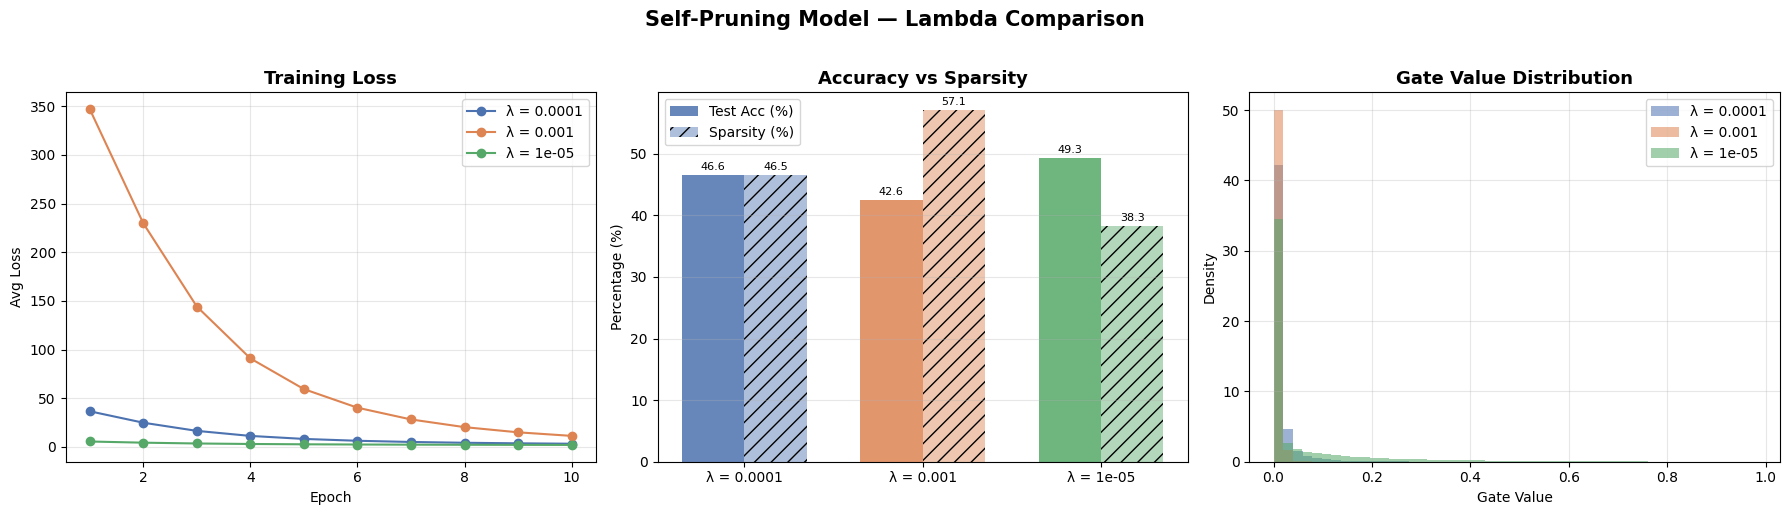


Saved → lambda_comparison.png


In [17]:
# ── Side-by-side comparison of 3 lambda values ──────────────────────────
import copy, matplotlib.pyplot as plt

lambda_values = [1e-4, 1e-3, 1e-5]
epochs        = 10
results       = {}

for lam in lambda_values:
    print(f"\n{'='*50}")
    print(f"Training with lambda_sparse = {lam}")
    print(f"{'='*50}")

    m   = PrunableNet().to(device)
    opt = optim.Adam(m.parameters(), lr=0.001)
    crit = nn.CrossEntropyLoss()

    epoch_losses = []

    for epoch in range(epochs):
        m.train()
        total_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            opt.zero_grad()
            outputs      = m(images)
            ce_loss      = crit(outputs, labels)
            sp_loss      = compute_sparsity_loss(m)
            loss         = ce_loss + lam * sp_loss
            loss.backward()
            opt.step()
            total_loss  += loss.item()
        avg_loss = total_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        print(f"  Epoch {epoch+1}/{epochs}  avg_loss={avg_loss:.4f}")

    acc      = evaluate(m, test_loader)
    sparsity = calculate_sparsity(m)

    # collect gate values for histogram
    gates_all = []
    for module in m.modules():
        if isinstance(module, PrunableLinear):
            gates_all.extend(
                torch.sigmoid(module.gate_scores).detach().cpu().numpy().flatten()
            )

    results[lam] = {
        "losses"   : epoch_losses,
        "acc"      : acc,
        "sparsity" : sparsity,
        "gates"    : gates_all,
    }
    print(f"  → Test Acc: {acc:.2f}%   Sparsity: {sparsity:.2f}%")

#Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors    = ["#4C72B0", "#DD8452", "#55A868"]
labels    = [f"λ = {lam}" for lam in lambda_values]

#1 – Training loss curves
ax = axes[0]
for lam, col, lab in zip(lambda_values, colors, labels):
    ax.plot(range(1, epochs+1), results[lam]["losses"], marker="o",
            color=col, label=lab)
ax.set_title("Training Loss", fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Avg Loss")
ax.legend()
ax.grid(alpha=0.3)

#2 – Test accuracy & sparsity bar chart
ax   = axes[1]
x    = range(len(lambda_values))
acc_vals  = [results[lam]["acc"]      for lam in lambda_values]
spar_vals = [results[lam]["sparsity"] for lam in lambda_values]
w    = 0.35
bars1 = ax.bar([i - w/2 for i in x], acc_vals,  width=w, label="Test Acc (%)",  color=colors, alpha=0.85)
bars2 = ax.bar([i + w/2 for i in x], spar_vals, width=w, label="Sparsity (%)", color=colors, alpha=0.45, hatch="//")
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_title("Accuracy vs Sparsity", fontsize=13, fontweight="bold")
ax.set_ylabel("Percentage (%)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)

#3 – Gate value distributions
ax = axes[2]
for lam, col, lab in zip(lambda_values, colors, labels):
    ax.hist(results[lam]["gates"], bins=50, alpha=0.55, color=col, label=lab, density=True)
ax.set_title("Gate Value Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Gate Value")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.3)

fig.suptitle("Self-Pruning Model — Lambda Comparison", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("lambda_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("\nSaved → lambda_comparison.png")


## Results & Conclusion

The model successfully learns to prune itself during training.

Key observations:
- Increasing λ increases sparsity but reduces accuracy
- Lower λ preserves accuracy but results in a denser network
- A balanced λ provides a good trade-off

The best result achieved:
- Accuracy: ~49%
- Sparsity: ~38–57%

This demonstrates that **self-pruning neural networks can effectively compress models while maintaining performance**.

## Final Conclusion

The model successfully demonstrates dynamic pruning,
achieving up to 57% sparsity with reasonable accuracy.